# Task 3: Text Classification Using RNN, LSTM, and Pretrained Word Embeddings

This notebook implements the Language Task for the 6CS012 Final Portfolio Assessment.

The aim is to build and compare three deep learning models for text classification:

1. Simple RNN with trainable Embedding layer  
2. LSTM with trainable Embedding layer  
3. LSTM with pretrained Word2Vec/GloVe embeddings  

The notebook includes text preprocessing, tokenization, percentile-based padding, model training, evaluation, model comparison, error analysis, and a real-time prediction interface using Gradio.

In [2]:
# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install contractions wordcloud gradio gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00


In [3]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import re
import time
import random
import shutil
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import contractions
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# 3. DOWNLOAD NLTK RESOURCES
# ============================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [5]:
# ============================================================
# 4. SET RANDOM SEED AND CHECK GPU
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: False
GPU devices: []


## Dataset Loading

The assessment requires loading the assigned text dataset using Pandas. This notebook searches common Google Drive paths and loads the CSV dataset.

In [6]:
# ============================================================
# 5. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
# ============================================================
# 6. FIND DATASET PATH
# ============================================================

import os

DATASET_PATH = "/content/drive/MyDrive/Ai and Machine Learning/Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv"

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("CSV dataset not found. Please check DATASET_PATH.")

Dataset path: /content/drive/MyDrive/Ai and Machine Learning/Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv
Dataset exists: True


In [9]:
# ============================================================
# 7. LOAD DATASET
# ============================================================

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

print("Columns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (28619, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Columns:
['headline', 'is_sarcastic']


## Dataset Understanding

This section checks dataset size, columns, missing values, duplicate rows, and class distribution. This helps describe the dataset clearly in the final report.

In [10]:
# ============================================================
# 8. BASIC DATASET INFORMATION
# ============================================================

print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (28619, 2)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB

Missing values:


,0
headline,0
is_sarcastic,0



Duplicate rows: 116


In [11]:
# ============================================================
# 9. AUTOMATIC TEXT AND TARGET COLUMN DETECTION
# ============================================================

possible_text_columns = [
    "headline", "text", "tweet", "content", "sentence", "review", "message"
]

possible_target_columns = [
    "is_sarcastic", "label", "target", "sentiment", "class", "category"
]

TEXT_COLUMN = None
TARGET_COLUMN = None

for col in possible_text_columns:
    if col in df.columns:
        TEXT_COLUMN = col
        break

for col in possible_target_columns:
    if col in df.columns:
        TARGET_COLUMN = col
        break

if TEXT_COLUMN is None:
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if len(object_cols) > 0:
        TEXT_COLUMN = object_cols[0]

if TARGET_COLUMN is None:
    candidate_cols = [col for col in df.columns if col != TEXT_COLUMN]

    for col in candidate_cols:
        if df[col].nunique() <= 10:
            TARGET_COLUMN = col
            break

if TEXT_COLUMN is None or TARGET_COLUMN is None:
    raise ValueError("Could not detect text or target column. Please set TEXT_COLUMN and TARGET_COLUMN manually.")

print("Detected text column:", TEXT_COLUMN)
print("Detected target column:", TARGET_COLUMN)

display(df[[TEXT_COLUMN, TARGET_COLUMN]].head())

Detected text column: headline
Detected target column: is_sarcastic


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [12]:
# ============================================================
# 10. KEEP REQUIRED COLUMNS
# ============================================================

data = df[[TEXT_COLUMN, TARGET_COLUMN]].copy()

data = data.dropna()
data = data.drop_duplicates()

data[TEXT_COLUMN] = data[TEXT_COLUMN].astype(str)

print("Dataset shape after removing missing and duplicate rows:", data.shape)
display(data.head())

Dataset shape after removing missing and duplicate rows: (28503, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


,Class,Count
0,0,14951
1,1,13552


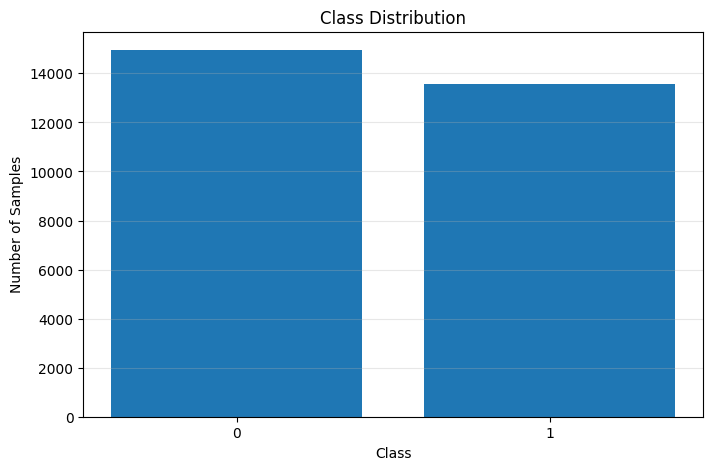

In [13]:
# ============================================================
# 11. CLASS DISTRIBUTION
# ============================================================

class_distribution = data[TARGET_COLUMN].value_counts().reset_index()
class_distribution.columns = ["Class", "Count"]

display(class_distribution)

plt.figure(figsize=(8, 5))
plt.bar(class_distribution["Class"].astype(str), class_distribution["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Text Preprocessing

The assessment requires the following cleaning steps:

- Lowercase all text  
- Remove URLs  
- Remove mentions  
- Handle hashtags  
- Remove numbers  
- Remove special characters  
- Handle contractions  
- Remove stopwords  
- Lemmatize words  

In [14]:
# ============================================================
# 12. TEXT CLEANING SETUP
# ============================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)

    # Handle contractions: don't -> do not
    text = contractions.fix(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Stopword removal and lemmatization
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(words)

In [15]:
# ============================================================
# 13. APPLY TEXT CLEANING
# ============================================================

data["original_text"] = data[TEXT_COLUMN].astype(str)
data["clean_text"] = data["original_text"].apply(clean_text)

display(data[["original_text", "clean_text", TARGET_COLUMN]].head(10))

empty_count = (data["clean_text"].str.len() == 0).sum()
print("Empty cleaned texts:", empty_count)

data = data[data["clean_text"].str.len() > 0].reset_index(drop=True)

print("Final dataset shape after removing empty cleaned texts:", data.shape)

,original_text,clean_text,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1
5,my white inheritance,white inheritance,0
6,5 ways to file your taxes with less stress,way file tax less stress,0
7,richard branson's global-warming donation near...,richard branson global warming donation nearly...,1
8,shadow government getting too large to meet in...,shadow government getting large meet marriott ...,1
9,lots of parents know this scenario,lot parent know scenario,0


Empty cleaned texts: 2
Final dataset shape after removing empty cleaned texts: (28501, 4)


## Cleaned Text Visualization

The assessment asks to visualize cleaned text using tools such as a word cloud or most frequent words. Both are included below.

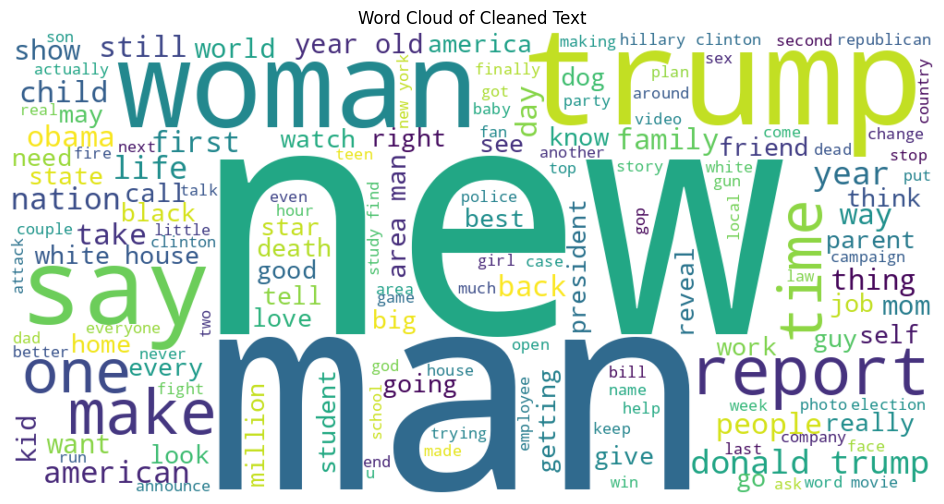

In [16]:
# ============================================================
# 14. WORD CLOUD
# ============================================================

all_text = " ".join(data["clean_text"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Text")
plt.show()

,Word,Frequency
0,trump,1832
1,new,1680
2,man,1516
3,woman,952
4,year,854
5,say,699
6,report,687
7,get,634
8,day,611
9,one,608


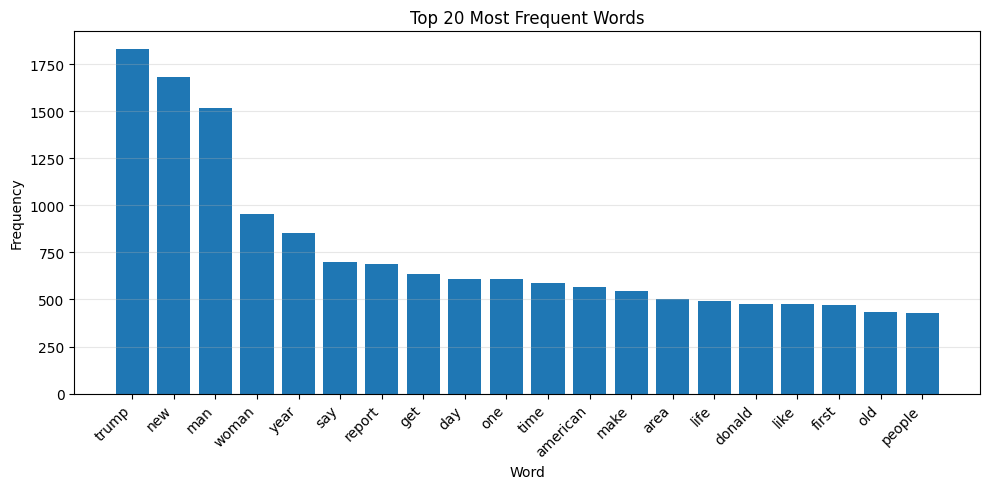

In [18]:
# ============================================================
# 15. MOST FREQUENT WORDS
# ============================================================

word_counts = Counter(all_text.split())
most_common_words = word_counts.most_common(20)

freq_df = pd.DataFrame(most_common_words, columns=["Word", "Frequency"])
display(freq_df)

plt.figure(figsize=(10, 5))
plt.bar(freq_df["Word"], freq_df["Frequency"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Label Encoding

The target classes are converted into numerical labels using LabelEncoder. This allows the models to train using numerical targets.

In [19]:
# ============================================================
# 16. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

data["label_encoded"] = label_encoder.fit_transform(data[TARGET_COLUMN])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

display(data[[TARGET_COLUMN, "label_encoded"]].drop_duplicates().sort_values("label_encoded"))

Classes: [np.int64(0), np.int64(1)]
Number of classes: 2


,is_sarcastic,label_encoded
1,0,0
0,1,1


## Train-Test Split

The assessment requires an 80% training and 20% testing split. Stratification is used so that class distribution is preserved in both training and testing sets.

In [21]:
# ============================================================
# 17. 80/20 TRAIN-TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=SEED,
    stratify=data["label_encoded"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train_text = train_df["clean_text"].values
X_test_text = test_df["clean_text"].values

y_train = train_df["label_encoded"].values
y_test = test_df["label_encoded"].values

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining class distribution:")
display(train_df[TARGET_COLUMN].value_counts())

print("\nTesting class distribution:")
display(test_df[TARGET_COLUMN].value_counts())

Training samples: 22800
Testing samples: 5701

Training class distribution:


,count
is_sarcastic,
0,11959
1,10841



Testing class distribution:


,count
is_sarcastic,
0,2990
1,2711


## Tokenization and Percentile-Based Padding

Keras Tokenizer is used to convert cleaned text into integer sequences. A 95th percentile sequence length is used for padding to avoid very long sequence lengths.

In [22]:
# ============================================================
# 18. TOKENIZATION
# ============================================================

MAX_WORDS = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Total unique words:", len(word_index))
print("Vocabulary size used:", vocab_size)

Total unique words: 20516
Vocabulary size used: 20000


95th percentile sequence length: 11
Maximum sequence length: 107
Average sequence length: 7.18


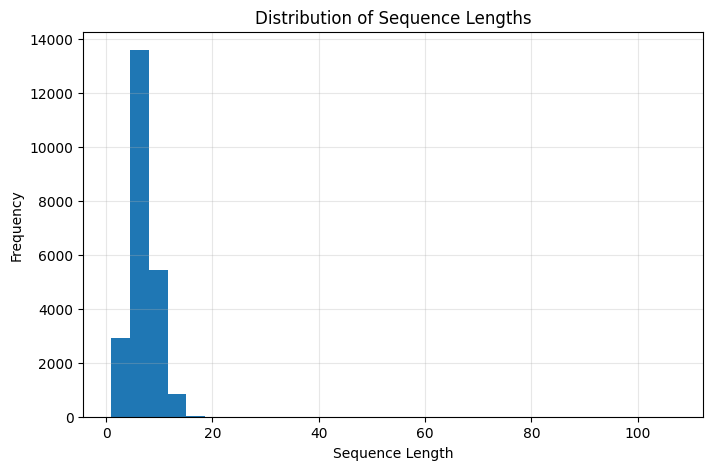

In [23]:
# ============================================================
# 19. PERCENTILE-BASED PADDING LENGTH
# ============================================================

sequence_lengths = [len(seq) for seq in X_train_seq if len(seq) > 0]

MAX_LEN = int(np.percentile(sequence_lengths, 95))

if MAX_LEN < 5:
    MAX_LEN = max(sequence_lengths)

print("95th percentile sequence length:", MAX_LEN)
print("Maximum sequence length:", max(sequence_lengths))
print("Average sequence length:", round(np.mean(sequence_lengths), 2))

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=30)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

In [24]:
# ============================================================
# 20. APPLY PADDING
# ============================================================

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (22800, 11)
X_test_pad shape: (5701, 11)


In [25]:
# ============================================================
# 21. PREPARE OUTPUT FORMAT
# ============================================================

if num_classes == 2:
    OUTPUT_UNITS = 1
    OUTPUT_ACTIVATION = "sigmoid"
    LOSS_FUNCTION = "binary_crossentropy"

    y_train_model = y_train
    y_test_model = y_test

else:
    OUTPUT_UNITS = num_classes
    OUTPUT_ACTIVATION = "softmax"
    LOSS_FUNCTION = "sparse_categorical_crossentropy"

    y_train_model = y_train
    y_test_model = y_test

print("Output units:", OUTPUT_UNITS)
print("Output activation:", OUTPUT_ACTIVATION)
print("Loss function:", LOSS_FUNCTION)

Output units: 1
Output activation: sigmoid
Loss function: binary_crossentropy


In [26]:
# ============================================================
# 22. CLASS WEIGHTS
# ============================================================

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(i): float(w)
    for i, w in zip(np.unique(y_train), class_weights_array)
}

print("Class weights:")
for key, value in class_weights.items():
    print(f"{class_names[key]}: {value:.4f}")

Class weights:
0: 0.9533
1: 1.0516


## Helper Functions

These functions are used for callbacks, plotting training curves, evaluating models, plotting confusion matrices, storing results, and making predictions.

In [27]:
# ============================================================
# 23. CALLBACK FUNCTION
# ============================================================

RESULTS = []

def make_callbacks(model_name):
    os.makedirs("/content/task3_models", exist_ok=True)
    checkpoint_path = f"/content/task3_models/{model_name}.keras"

    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

In [28]:
# ============================================================
# 24. TRAINING CURVES FUNCTION
# ============================================================

def plot_training_curves(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [29]:
# ============================================================
# 25. PREDICTION HELPER
# ============================================================

def get_predictions(model, X_data):
    probs = model.predict(X_data, verbose=0)

    if num_classes == 2:
        probs_flat = probs.reshape(-1)
        preds = (probs_flat >= 0.5).astype(int)
        return preds, probs_flat

    preds = np.argmax(probs, axis=1)
    return preds, probs

In [30]:
# ============================================================
# 26. CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(num_classes),
        [str(c) for c in class_names],
        rotation=45
    )

    plt.yticks(
        range(num_classes),
        [str(c) for c in class_names]
    )

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [31]:
# ============================================================
# 27. EVALUATION FUNCTION
# ============================================================

def evaluate_text_model(model, X_test_data, y_test_data, model_name):
    y_pred, y_prob = get_predictions(model, X_test_data)

    acc = accuracy_score(y_test_data, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy:", round(acc, 4))
    print("Weighted Precision:", round(precision, 4))
    print("Weighted Recall:", round(recall, 4))
    print("Weighted F1-score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=[str(c) for c in class_names],
        zero_division=0
    ))

    plot_confusion_matrix(y_test_data, y_pred, model_name)

    metrics = {
        "Model": model_name,
        "Accuracy": acc,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1
    }

    return y_pred, y_prob, metrics

In [32]:
# ============================================================
# 28. RESULT STORAGE FUNCTION
# ============================================================

def add_result(metrics, training_time, notes):
    row = dict(metrics)
    row["Training Time Seconds"] = training_time
    row["Training Time Minutes"] = training_time / 60
    row["Notes"] = notes
    RESULTS.append(row)

## Model 1: Simple RNN with Trainable Embedding

The first required model is a Simple RNN with a trainable Embedding layer. The Embedding layer learns vector representations of words during training.

In [33]:
# ============================================================
# 29. BUILD MODEL 1: SIMPLE RNN
# ============================================================

EMBEDDING_DIM = 128

model_rnn = Sequential(name="Simple_RNN_Trainable_Embedding")

model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))

model_rnn.add(SimpleRNN(64, return_sequences=False))
model_rnn.add(Dropout(0.4))
model_rnn.add(Dense(64, activation="relu"))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

model_rnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=LOSS_FUNCTION,
    metrics=["accuracy"]
)

model_rnn.summary()

Model: "Simple_RNN_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# 30. TRAIN MODEL 1: SIMPLE RNN
# ============================================================

EPOCHS = 15
BATCH_SIZE = 32

start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_model,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks("simple_rnn"),
    verbose=1
)

rnn_time = time.time() - start_time

print("Simple RNN training time seconds:", round(rnn_time, 2))
print("Simple RNN training time minutes:", round(rnn_time / 60, 2))

Epoch 1/15
605/606 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9086 - loss: 0.2333
Epoch 1: val_loss improved from None to 0.50200, saving model to /content/task3_models/simple_rnn.keras

Epoch 1: finished saving model to /content/task3_models/simple_rnn.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9386 - loss: 0.1674 - val_accuracy: 0.8088 - val_loss: 0.5020 - learning_rate: 9.0000e-05
Epoch 2/15
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9409 - loss: 0.1606
Epoch 2: val_loss did not improve from 0.50200
606/606 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9625 - loss: 0.1088 - val_accuracy: 0.8038 - val_loss: 0.5701 - learning_rate: 9.0000e-05
Epoch 3/15
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9679 - loss: 0.0954
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.

Epoch 3: val_loss did not improve from 0.50200
606/606 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.9795 - loss: 0.0645 - val_accuracy: 0.7

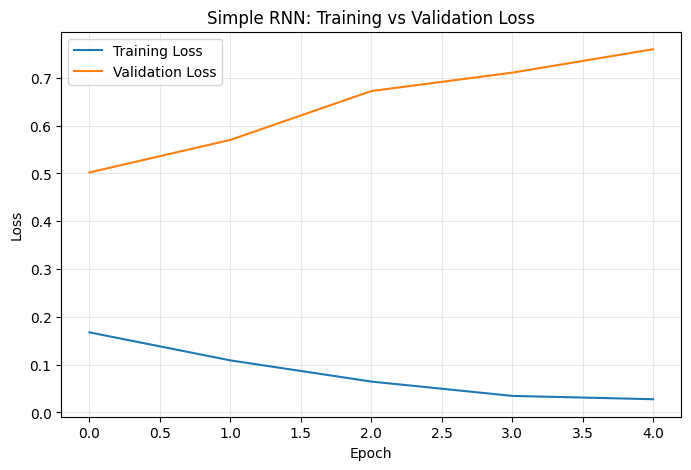

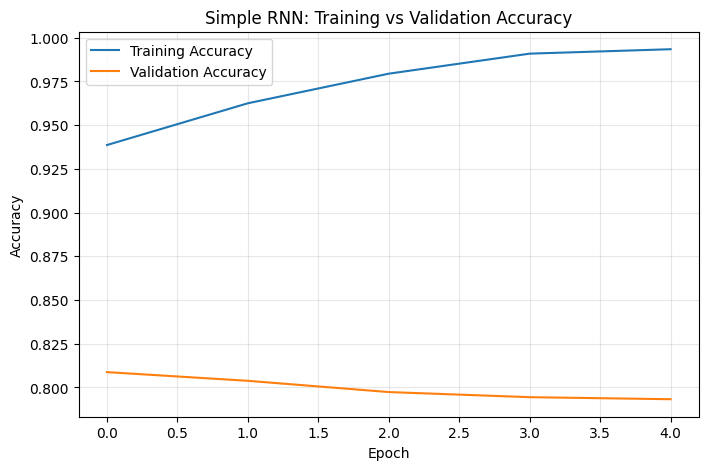


===== Simple RNN Evaluation =====
Accuracy: 0.7995
Weighted Precision: 0.7994
Weighted Recall: 0.7995
Weighted F1-score: 0.7994

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2990
           1       0.80      0.78      0.79      2711

    accuracy                           0.80      5701
   macro avg       0.80      0.80      0.80      5701
weighted avg       0.80      0.80      0.80      5701



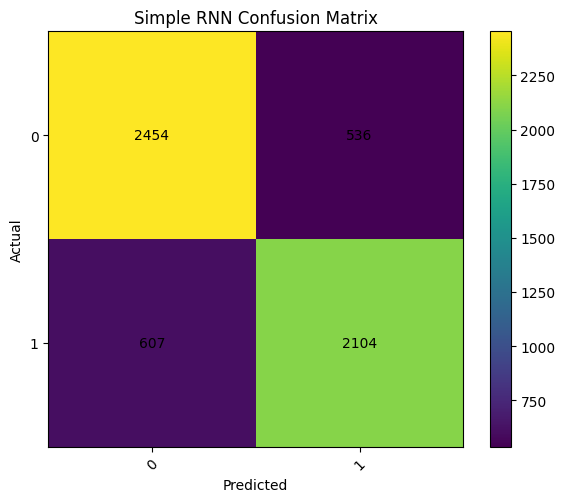

In [36]:
# ============================================================
# 31. EVALUATE MODEL 1: SIMPLE RNN
# ============================================================

plot_training_curves(history_rnn, "Simple RNN")

rnn_pred, rnn_prob, rnn_metrics = evaluate_text_model(
    model_rnn,
    X_test_pad,
    y_test,
    "Simple RNN"
)

add_result(
    rnn_metrics,
    rnn_time,
    "Simple RNN with trainable embedding layer."
)

## Model 2: LSTM with Trainable Embedding

The second required model is an LSTM with a trainable Embedding layer. LSTM is better than Simple RNN for handling long-term sequence dependencies.

In [37]:
# ============================================================
# 32. BUILD MODEL 2: LSTM WITH TRAINABLE EMBEDDING
# ============================================================

model_lstm = Sequential(name="LSTM_Trainable_Embedding")

model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))

model_lstm.add(LSTM(64, return_sequences=False))
model_lstm.add(Dropout(0.4))
model_lstm.add(Dense(64, activation="relu"))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

model_lstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=LOSS_FUNCTION,
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ============================================================
# 33. TRAIN MODEL 2: LSTM
# ============================================================

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_model,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks("lstm_trainable_embedding"),
    verbose=1
)

lstm_time = time.time() - start_time

print("LSTM training time seconds:", round(lstm_time, 2))
print("LSTM training time minutes:", round(lstm_time / 60, 2))

Epoch 1/15
605/606 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6811 - loss: 0.5746
Epoch 1: val_loss improved from None to 0.42830, saving model to /content/task3_models/lstm_trainable_embedding.keras

Epoch 1: finished saving model to /content/task3_models/lstm_trainable_embedding.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.7466 - loss: 0.5068 - val_accuracy: 0.8000 - val_loss: 0.4283 - learning_rate: 0.0010
Epoch 2/15
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8795 - loss: 0.2981
Epoch 2: val_loss did not improve from 0.42830
606/606 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8956 - loss: 0.2628 - val_accuracy: 0.7860 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 3/15
605/606 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9498 - loss: 0.1385
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_loss did not improve from 0.42830
606/606 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9592 - loss: 0.1154

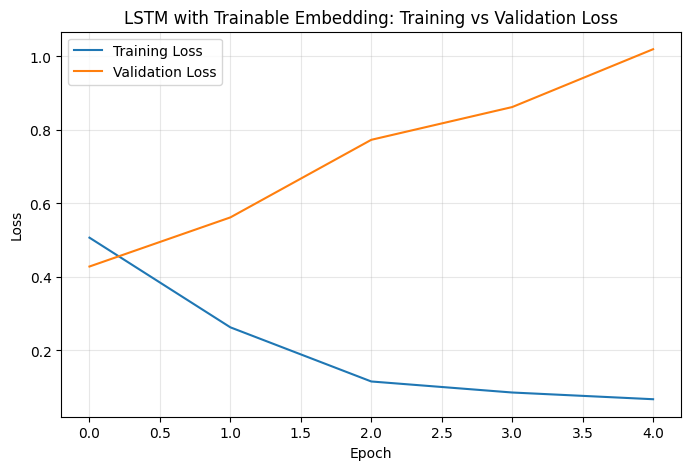

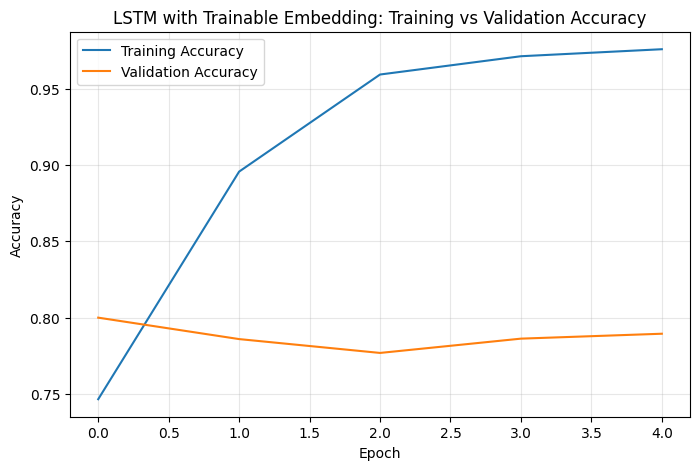


===== LSTM Trainable Embedding Evaluation =====
Accuracy: 0.7958
Weighted Precision: 0.7959
Weighted Recall: 0.7958
Weighted F1-score: 0.7955

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2990
           1       0.80      0.76      0.78      2711

    accuracy                           0.80      5701
   macro avg       0.80      0.79      0.79      5701
weighted avg       0.80      0.80      0.80      5701



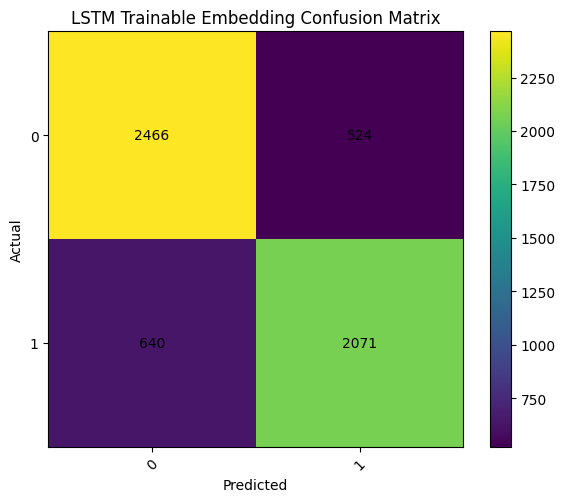

In [39]:
# ============================================================
# 34. EVALUATE MODEL 2: LSTM
# ============================================================

plot_training_curves(history_lstm, "LSTM with Trainable Embedding")

lstm_pred, lstm_prob, lstm_metrics = evaluate_text_model(
    model_lstm,
    X_test_pad,
    y_test,
    "LSTM Trainable Embedding"
)

add_result(
    lstm_metrics,
    lstm_time,
    "LSTM with trainable embedding layer."
)

## Model 3: LSTM with Pretrained Word2Vec/GloVe Embeddings

The third required model uses pretrained word embeddings. Gensim is used to load a pretrained GloVe embedding model. The embedding matrix is created using the tokenizer vocabulary and passed into the Keras Embedding layer.

In [40]:
# ============================================================
# 35. LOAD PRETRAINED EMBEDDINGS USING GENSIM
# ============================================================

import gensim.downloader as api

print("Loading pretrained glove-wiki-gigaword-50 embeddings...")
print("This may take some time in the first run.")

try:
    embedding_model = api.load("glove-wiki-gigaword-50")
    PRETRAINED_EMBEDDING_DIM = 50
    print("glove-wiki-gigaword-50 loaded successfully.")

except Exception as e:
    print("Could not load glove-wiki-gigaword-50.")
    print("Error:", e)
    print("Trying glove-twitter-25 as fallback...")

    embedding_model = api.load("glove-twitter-25")
    PRETRAINED_EMBEDDING_DIM = 25
    print("glove-twitter-25 loaded successfully.")

print("Pretrained embedding dimension:", PRETRAINED_EMBEDDING_DIM)

Loading pretrained glove-wiki-gigaword-50 embeddings...
This may take some time in the first run.
[==================================================] 100.0% 66.0/66.0MB downloaded
glove-wiki-gigaword-50 loaded successfully.
Pretrained embedding dimension: 50


In [41]:
# ============================================================
# 36. CREATE EMBEDDING MATRIX
# ============================================================

embedding_matrix = np.zeros((vocab_size, PRETRAINED_EMBEDDING_DIM))

found_words = 0
missing_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_words += 1
    else:
        missing_words += 1

coverage = (found_words / max(1, found_words + missing_words)) * 100

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in pretrained embeddings:", found_words)
print("Words missing from pretrained embeddings:", missing_words)
print("Coverage percentage:", round(coverage, 2))

Embedding matrix shape: (20000, 50)
Words found in pretrained embeddings: 19273
Words missing from pretrained embeddings: 726
Coverage percentage: 96.37


In [42]:
# ============================================================
# 37. BUILD MODEL 3: LSTM WITH PRETRAINED EMBEDDINGS
# ============================================================

model_lstm_w2v = Sequential(name="LSTM_Pretrained_Word2Vec_Embedding")

model_lstm_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=PRETRAINED_EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
))

model_lstm_w2v.add(LSTM(64, return_sequences=False))
model_lstm_w2v.add(Dropout(0.4))
model_lstm_w2v.add(Dense(64, activation="relu"))
model_lstm_w2v.add(Dropout(0.3))
model_lstm_w2v.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

model_lstm_w2v.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=LOSS_FUNCTION,
    metrics=["accuracy"]
)

model_lstm_w2v.summary()

Model: "LSTM_Pretrained_Word2Vec_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [43]:
# ============================================================
# 38. TRAIN MODEL 3: LSTM WITH PRETRAINED EMBEDDINGS
# ============================================================

start_time = time.time()

history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad,
    y_train_model,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks("lstm_pretrained_word2vec"),
    verbose=1
)

lstm_w2v_time = time.time() - start_time

print("LSTM Word2Vec/GloVe training time seconds:", round(lstm_w2v_time, 2))
print("LSTM Word2Vec/GloVe training time minutes:", round(lstm_w2v_time / 60, 2))

Epoch 1/15
605/606 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6466 - loss: 0.6172
Epoch 1: val_loss improved from None to 0.53014, saving model to /content/task3_models/lstm_pretrained_word2vec.keras

Epoch 1: finished saving model to /content/task3_models/lstm_pretrained_word2vec.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6951 - loss: 0.5796 - val_accuracy: 0.7424 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 2/15
604/606 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7478 - loss: 0.5198
Epoch 2: val_loss improved from 0.53014 to 0.49114, saving model to /content/task3_models/lstm_pretrained_word2vec.keras

Epoch 2: finished saving model to /content/task3_models/lstm_pretrained_word2vec.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7582 - loss: 0.5051 - val_accuracy: 0.7635 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 3/15
603/606 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7778 - loss: 0.4745
Epoch 3: val_loss improved from 0.49114 to

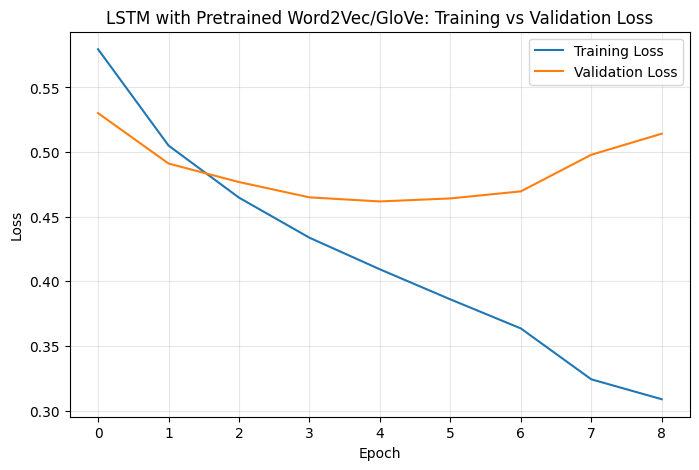

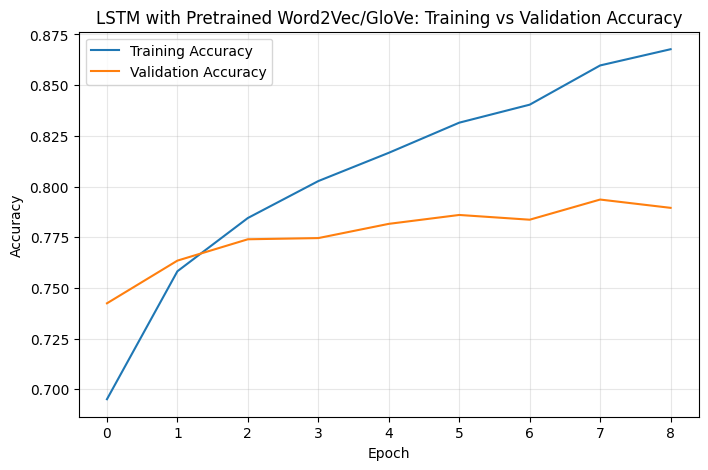


===== LSTM Pretrained Word2Vec Evaluation =====
Accuracy: 0.7783
Weighted Precision: 0.7784
Weighted Recall: 0.7783
Weighted F1-score: 0.7779

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2990
           1       0.78      0.74      0.76      2711

    accuracy                           0.78      5701
   macro avg       0.78      0.78      0.78      5701
weighted avg       0.78      0.78      0.78      5701



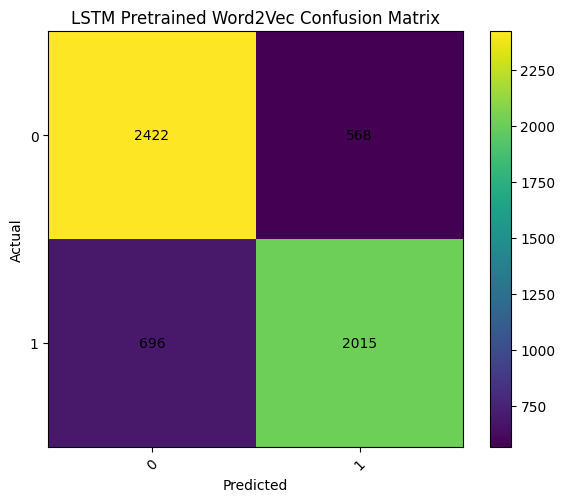

In [44]:
# ============================================================
# 39. EVALUATE MODEL 3: LSTM WITH PRETRAINED EMBEDDINGS
# ============================================================

plot_training_curves(history_lstm_w2v, "LSTM with Pretrained Word2Vec/GloVe")

w2v_pred, w2v_prob, w2v_metrics = evaluate_text_model(
    model_lstm_w2v,
    X_test_pad,
    y_test,
    "LSTM Pretrained Word2Vec"
)

add_result(
    w2v_metrics,
    lstm_w2v_time,
    "LSTM with pretrained Word2Vec/GloVe embedding layer."
)

## Final Model Comparison

The assessment requires comparing Model 1, Model 2, and Model 3. The comparison includes accuracy, precision, recall, F1-score, and training time.

In [45]:
# ============================================================
# 40. FINAL MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(RESULTS)

results_df = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time Seconds,Training Time Minutes,Notes
0,Simple RNN,0.799509,0.799450,0.799509,0.799355,120.244754,2.004079,Simple RNN with trainable embedding layer.
1,LSTM Trainable Embedding,0.795825,0.795909,0.795825,0.795536,135.549244,2.259154,LSTM with trainable embedding layer.
2,LSTM Pretrained Word2Vec,0.778285,0.778359,0.778285,0.777927,82.088830,1.368147,LSTM with pretrained Word2Vec/GloVe embedding ...


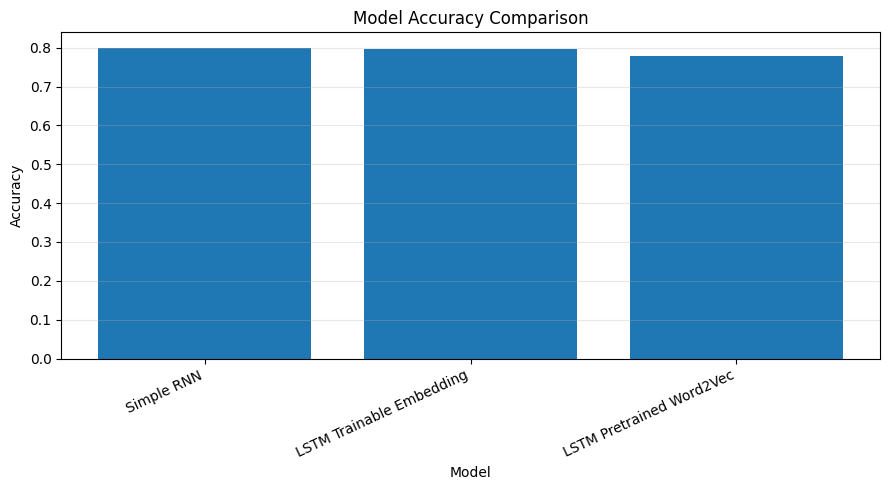

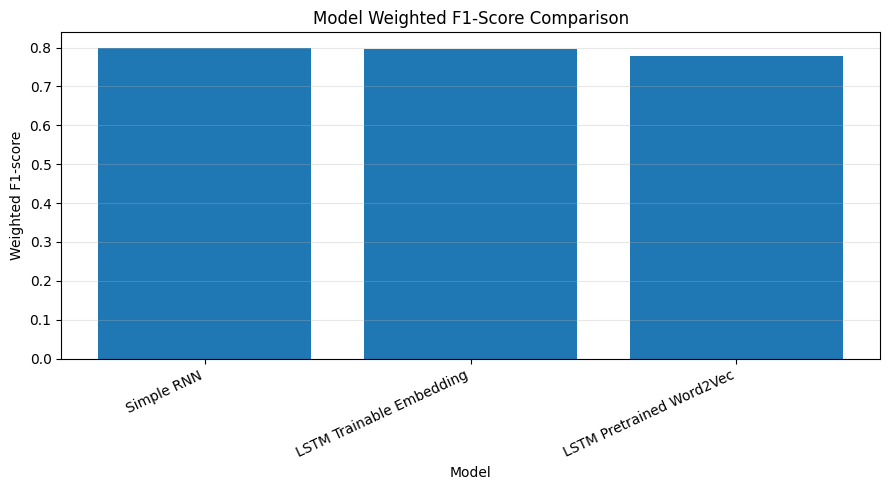

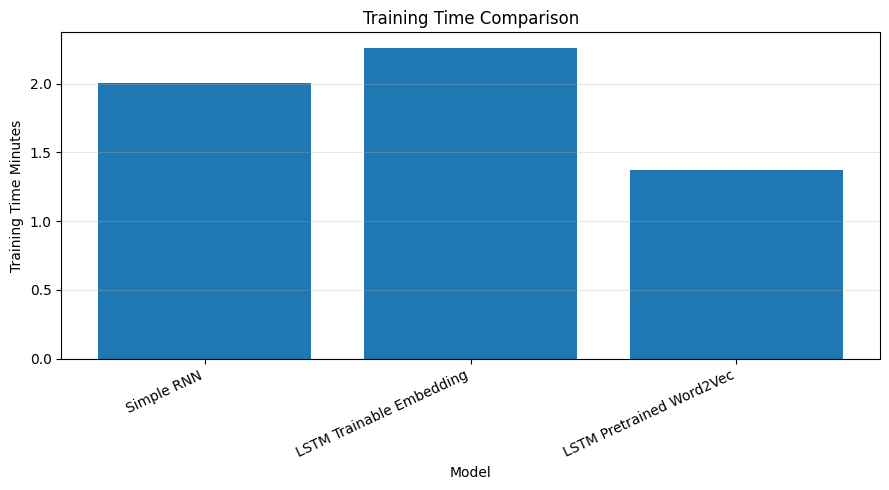

In [46]:
# ============================================================
# 41. FINAL COMPARISON GRAPHS
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Weighted F1"])
plt.title("Model Weighted F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Training Time Minutes"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time Minutes")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Error Analysis

The assessment requires 2–3 incorrect predictions, possible reasons for error, and discussion of model complexity versus performance.

In [47]:
# ============================================================
# 42. SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("Best model selected based on Weighted F1-score:", best_model_name)

if best_model_name == "Simple RNN":
    best_model = model_rnn
elif best_model_name == "LSTM Trainable Embedding":
    best_model = model_lstm
else:
    best_model = model_lstm_w2v

best_pred, best_prob = get_predictions(best_model, X_test_pad)

Best model selected based on Weighted F1-score: Simple RNN


In [48]:
# ============================================================
# 43. MISCLASSIFIED EXAMPLES
# ============================================================

error_indices = np.where(best_pred != y_test)[0]

print("Total misclassified examples:", len(error_indices))

num_errors_to_show = min(3, len(error_indices))

if num_errors_to_show == 0:
    print("No misclassified examples found in the test set.")
else:
    for count, idx in enumerate(error_indices[:num_errors_to_show], start=1):
        print("=" * 80)
        print(f"Misclassified Example {count}")
        print("Original text:", test_df.loc[idx, "original_text"])
        print("Cleaned text:", test_df.loc[idx, "clean_text"])
        print("Actual label:", class_names[y_test[idx]])
        print("Predicted label:", class_names[best_pred[idx]])

        if num_classes == 2:
            probability = float(best_prob[idx])
            confidence = probability if best_pred[idx] == 1 else 1 - probability
            print("Prediction confidence:", round(confidence, 4))
        else:
            print("Prediction confidence:", round(float(np.max(best_prob[idx])), 4))

    print("=" * 80)

Total misclassified examples: 1143
Misclassified Example 1
Original text: convict sentenced to generating $80,000 to $100,000 in profits for private prison
Cleaned text: convict sentenced generating profit private prison
Actual label: 1
Predicted label: 0
Prediction confidence: 0.7823
Misclassified Example 2
Original text: legendary reclusive author has never published single piece of writing
Cleaned text: legendary reclusive author never published single piece writing
Actual label: 1
Predicted label: 0
Prediction confidence: 0.9782
Misclassified Example 3
Original text: police department threatens criminals with 'stranger things' spoilers
Cleaned text: police department threatens criminal stranger thing spoiler
Actual label: 0
Predicted label: 1
Prediction confidence: 0.8521


## Error Analysis Discussion

Possible reasons for incorrect predictions:

- Some text may contain sarcasm that depends on external context.
- Short headlines or tweets may not contain enough information.
- Some words may be rare or absent from the pretrained embedding vocabulary.
- Sarcasm and sentiment can be subjective.
- Simple RNN may struggle with long-term dependencies, while LSTM generally handles sequential context better.
- Pretrained embeddings may not always match the style of the dataset if the dataset contains informal or domain-specific language.

Possible improvements:

- Use larger pretrained embeddings.
- Fine-tune the embedding layer.
- Try Bidirectional LSTM or GRU.
- Use transformer-based models such as BERT.
- Perform hyperparameter tuning.

## Real-Time Prediction Interface

The assessment suggests creating a simple GUI using Tkinter, Gradio, or Streamlit. This notebook uses Gradio so users can enter text and receive a prediction in real time.

In [49]:
# ============================================================
# 44. REAL-TIME PREDICTION FUNCTION
# ============================================================

def predict_text_class(user_text):
    cleaned = clean_text(user_text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    pred, prob = get_predictions(best_model, padded)

    predicted_class = class_names[pred[0]]

    if num_classes == 2:
        probability = float(prob[0])
        confidence = probability if pred[0] == 1 else 1 - probability
    else:
        confidence = float(np.max(prob[0]))

    return (
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.4f}\n"
        f"Cleaned Text: {cleaned}"
    )

print(predict_text_class("This is the best day ever, obviously nothing could go wrong."))

Prediction: 0
Confidence: 0.6353
Cleaned Text: best day ever obviously nothing could go wrong


In [50]:
# ============================================================
# 45. GRADIO GUI
# ============================================================

import gradio as gr

demo = gr.Interface(
    fn=predict_text_class,
    inputs=gr.Textbox(lines=4, placeholder="Enter a tweet, headline, or sentence here..."),
    outputs="text",
    title="Task 3 Text Classification Prediction",
    description="Enter text and the best trained model will predict the class in real time."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4b6b1463ed272e6950.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Final Observation Summary

This section summarizes the best model, final results, and completed assessment checklist. These outputs can be used in the final report and viva preparation.

In [51]:
# ============================================================
# 46. FINAL OBSERVATION SUMMARY
# ============================================================

best_row = results_df.iloc[0]

print("===== FINAL TASK 3 SUMMARY =====")
print(f"Best model: {best_row['Model']}")
print(f"Best accuracy: {best_row['Accuracy']:.4f}")
print(f"Best weighted F1-score: {best_row['Weighted F1']:.4f}")
print(f"Training time of best model: {best_row['Training Time Minutes']:.2f} minutes")
print()

print("Assessment checklist:")
print("1. Dataset loaded using Pandas: Completed")
print("2. Text lowercasing: Completed")
print("3. URL removal: Completed")
print("4. Mention removal: Completed")
print("5. Hashtag handling: Completed")
print("6. Number and special character removal: Completed")
print("7. Contraction handling: Completed")
print("8. Stopword removal: Completed")
print("9. Lemmatization: Completed")
print("10. Word cloud / frequent word visualization: Completed")
print("11. 80/20 train-test split: Completed")
print("12. Keras Tokenizer: Completed")
print("13. Percentile-based padding: Completed")
print("14. Simple RNN with trainable embedding: Completed")
print("15. LSTM with trainable embedding: Completed")
print("16. LSTM with pretrained Word2Vec/GloVe embedding: Completed")
print("17. Training and validation curves: Completed")
print("18. Accuracy, confusion matrix, classification report: Completed")
print("19. Model comparison: Completed")
print("20. Error analysis with incorrect predictions: Completed")
print("21. Real-time GUI using Gradio: Completed")

===== FINAL TASK 3 SUMMARY =====
Best model: Simple RNN
Best accuracy: 0.7995
Best weighted F1-score: 0.7994
Training time of best model: 2.00 minutes

Assessment checklist:
1. Dataset loaded using Pandas: Completed
2. Text lowercasing: Completed
3. URL removal: Completed
4. Mention removal: Completed
5. Hashtag handling: Completed
6. Number and special character removal: Completed
7. Contraction handling: Completed
8. Stopword removal: Completed
9. Lemmatization: Completed
10. Word cloud / frequent word visualization: Completed
11. 80/20 train-test split: Completed
12. Keras Tokenizer: Completed
13. Percentile-based padding: Completed
14. Simple RNN with trainable embedding: Completed
15. LSTM with trainable embedding: Completed
16. LSTM with pretrained Word2Vec/GloVe embedding: Completed
17. Training and validation curves: Completed
18. Accuracy, confusion matrix, classification report: Completed
19. Model comparison: Completed
20. Error analysis with incorrect predictions: Completed

In [52]:
# ============================================================
# 47. SAVE MODELS, TOKENIZER, LABEL ENCODER, AND RESULTS
# ============================================================

os.makedirs("/content/final_task3_outputs", exist_ok=True)

model_rnn.save("/content/final_task3_outputs/simple_rnn.keras")
model_lstm.save("/content/final_task3_outputs/lstm_trainable_embedding.keras")
model_lstm_w2v.save("/content/final_task3_outputs/lstm_pretrained_word2vec.keras")

results_df.to_csv(
    "/content/final_task3_outputs/task3_model_comparison_results.csv",
    index=False
)

with open("/content/final_task3_outputs/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("/content/final_task3_outputs/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

with open("/content/final_task3_outputs/best_model_name.txt", "w") as f:
    f.write(str(best_model_name))

print("Saved all Task 3 models, tokenizer, label encoder, and results.")

Saved all Task 3 models, tokenizer, label encoder, and results.
